# Examples


## Basic Imports

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

import numpy as np
from typing import Tuple

## Signal Generators

The following functions generate basic chirps, pulses, chirp trains, and pulse trains.

### Chirp Definition
The chirp employed is a linear ramp centered about $f_c$ Hz in frequency, traversing from frequency $f_0 = f_c - W/2$ to $f_1 = f_c + W/2$ in $T$ seconds.  The chirp rate $\rho = \frac{W}{2L}$ and the instantaneous frequency is

$$
f_i(t) = f_c - W/2 + \rho t
$$

such that the chirp is defined

$$
s_c(t) = (H(t) - H(t - L)) \mathrm{sin}(2 \pi f_i(t) t).
$$

### Pulse Definition
A pulse of length $L$ at frequency $f$ Hz is defined

$$
s_p(t) = (H(t) - H(t - L)) \mathrm{sin}(2 \pi f t).
$$

### Chirp Train Definition

A train of $N$ chirps of repetition interval T is then defined

$$
s_{ct}(t) = \sum_{n=0}^{N-1} s_c(t - nT).
$$

### Pulse Train Definition

A train of $N$ pulses is then similarly defined

$$
s_{pt}(t) = \sum_{n=0}^{N-1} s_p(t - nT).
$$


In [ ]:
from signal_generators import generate_chirp_train, generate_pulse_train
from signal_generators import visual_test_chirp_train, visual_test_pulse_train

## Visual Tests for Signal Generators

<IPython.core.display.Javascript object>


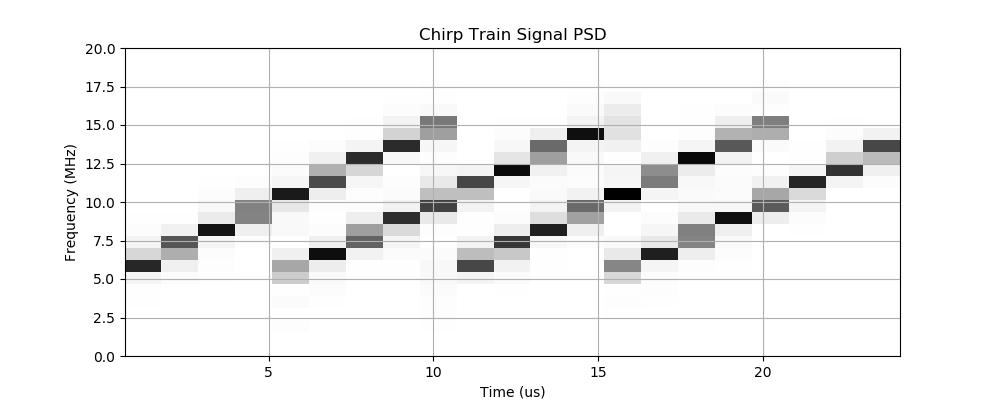

<IPython.core.display.Javascript object>


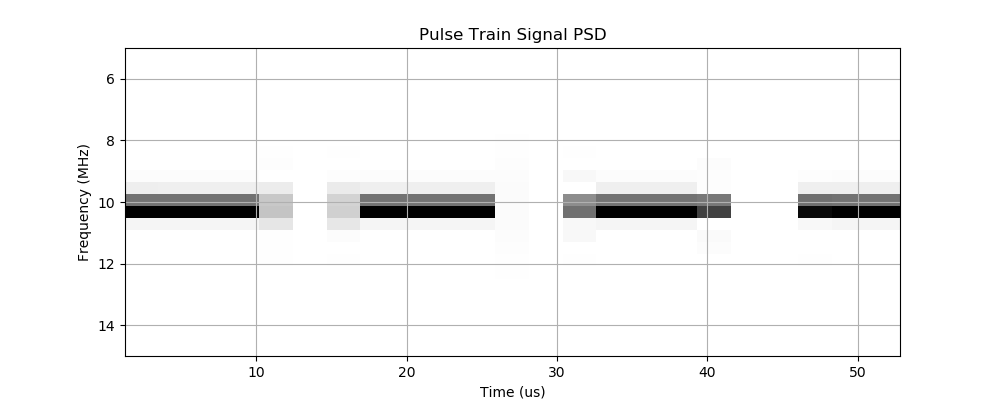

In [3]:
visual_test_chirp_train()
visual_test_pulse_train()

## Synthesizers to Generate Test Target Signals

In [ ]:
from target_synthesizers import (
    synthesize_range_sepparated_chirp_trains,
    synthesize_range_sepparated_pulse_trains,
)

from target_synthesizers import (
    visual_test_range_sepparated_chirp_trains,
    visual_test_range_sepparated_pulse_trains,
)

## Tests for Target Sythesizers

<IPython.core.display.Javascript object>


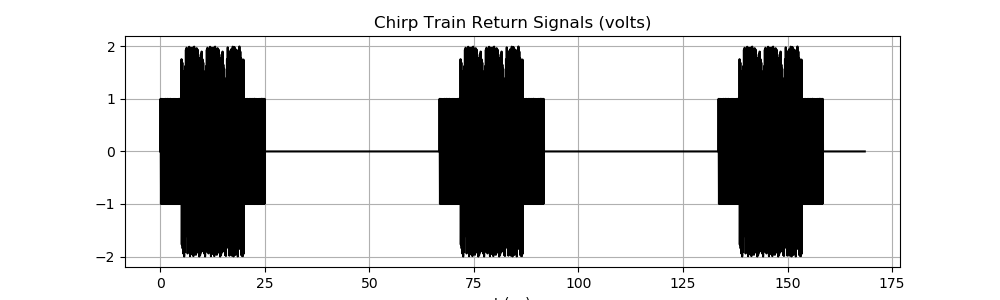

<IPython.core.display.Javascript object>


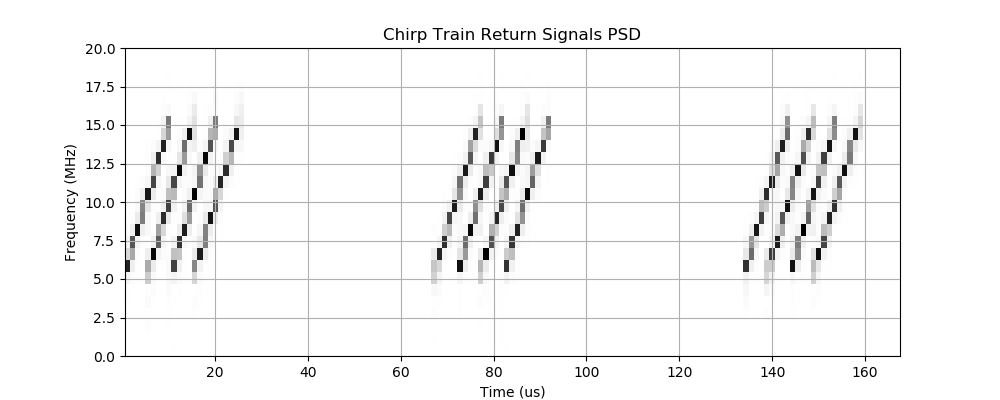

<IPython.core.display.Javascript object>


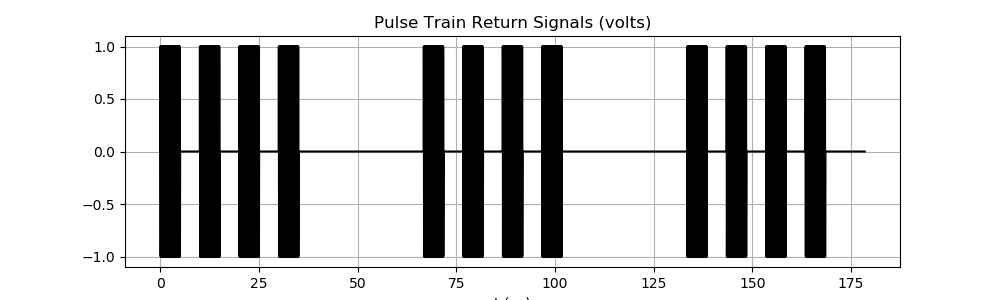

<IPython.core.display.Javascript object>


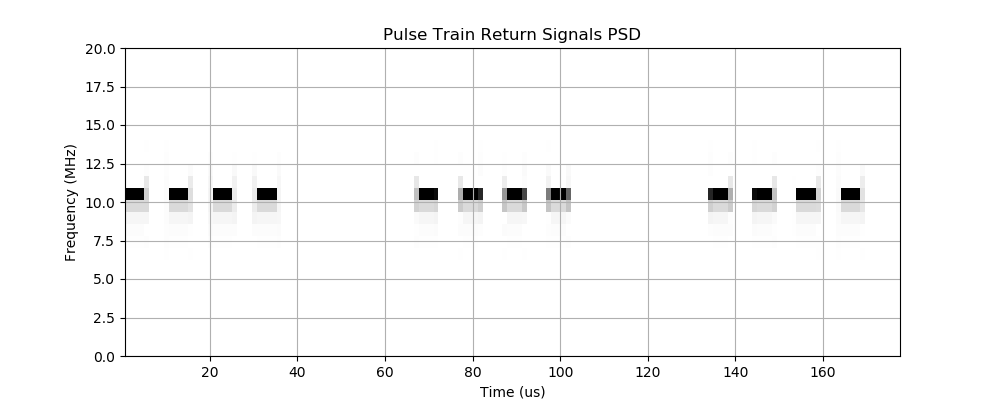

In [5]:
visual_test_range_sepparated_chirp_trains()
visual_test_range_sepparated_pulse_trains()

## Signal Processing Functions

In [ ]:
from signal_processing import (
    apply_fspl_attenuation,
    process_radar_receiver_chain,
)

from signal_generators import generate_chirp

## Test Signal Processing Functions

<IPython.core.display.Javascript object>


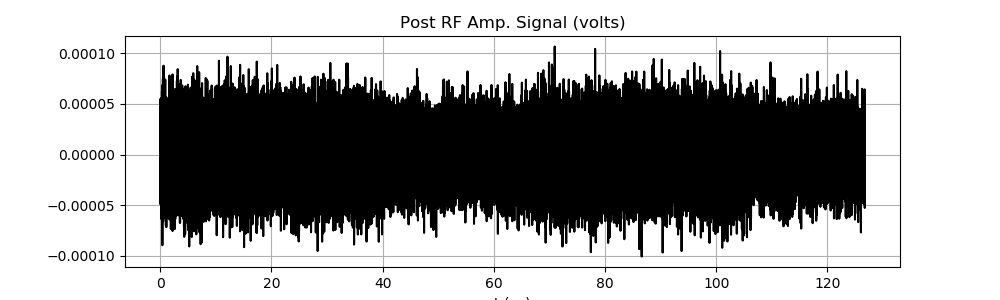

<IPython.core.display.Javascript object>


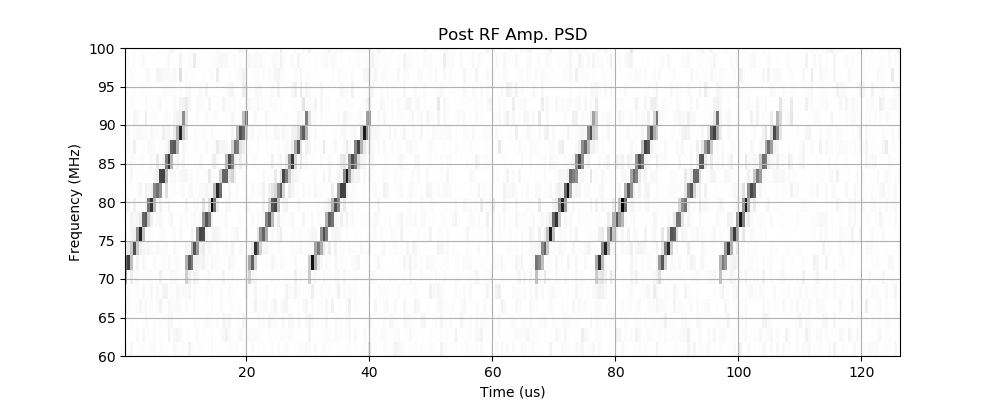

<IPython.core.display.Javascript object>


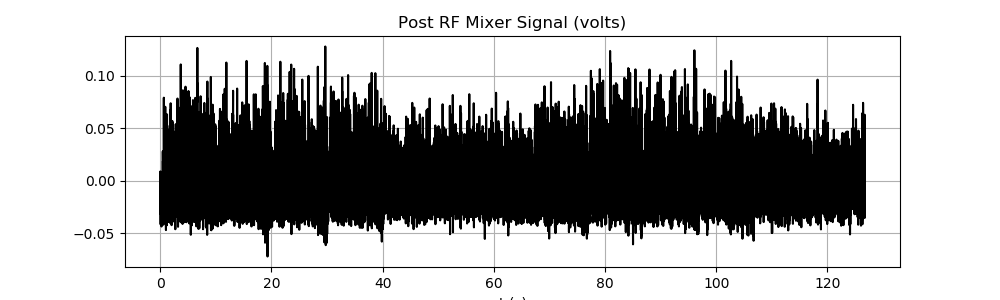

<IPython.core.display.Javascript object>


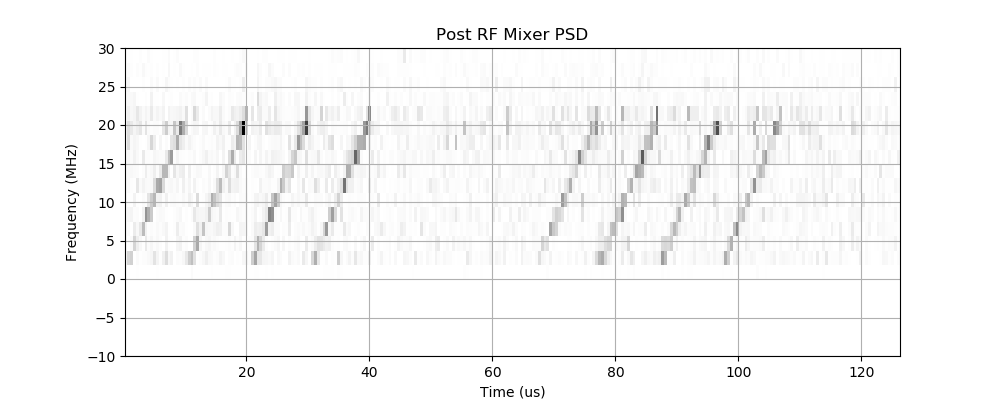

<IPython.core.display.Javascript object>


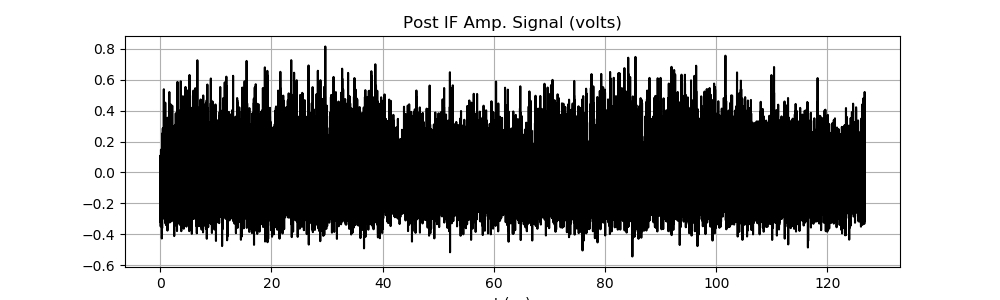

<IPython.core.display.Javascript object>


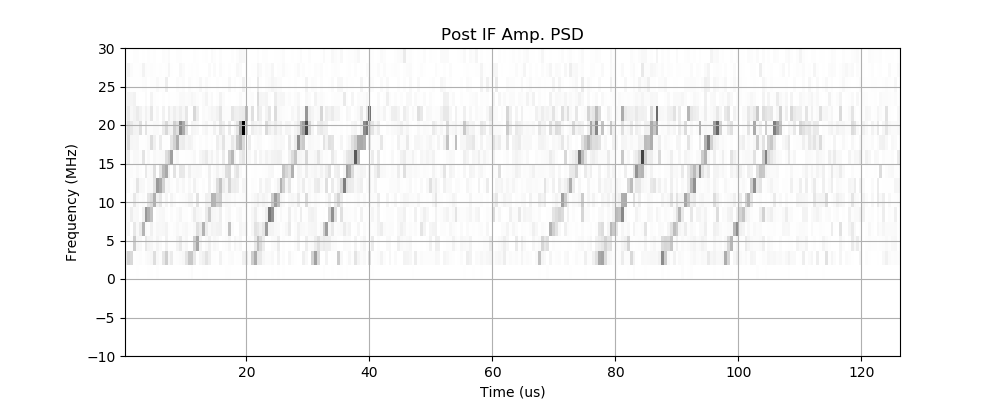

<IPython.core.display.Javascript object>


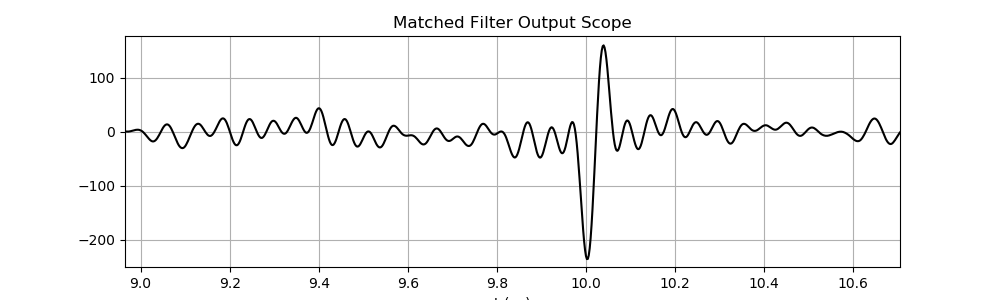

<IPython.core.display.Javascript object>


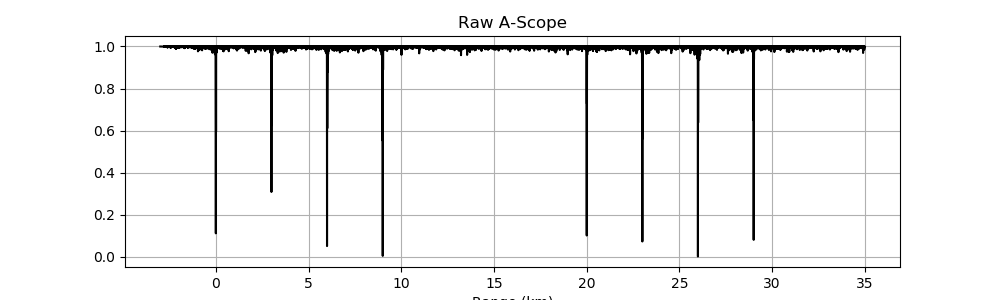

<IPython.core.display.Javascript object>


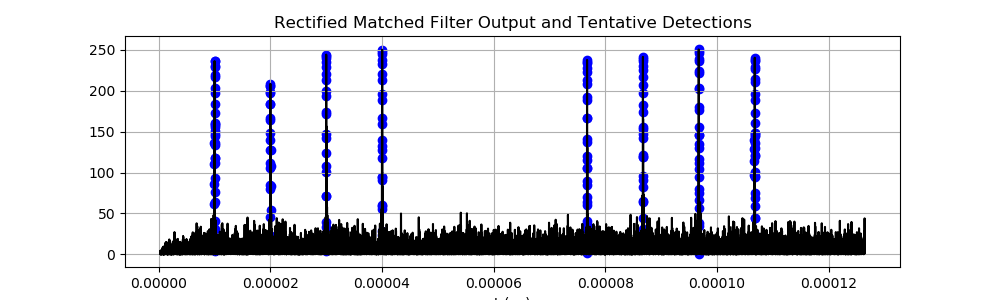

<IPython.core.display.Javascript object>


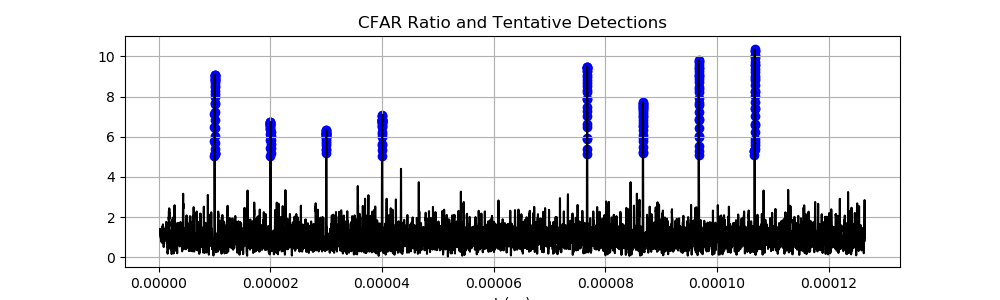

<IPython.core.display.Javascript object>


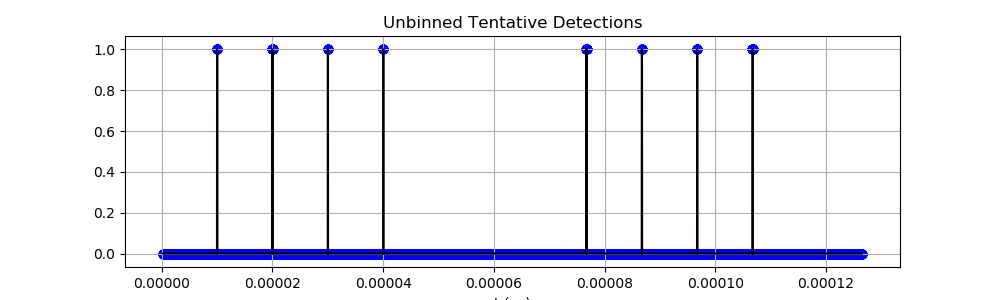

48.0


In [ ]:
# Test open loop radar receiver chain - chirp
center_frequency_hz = 80.0e6
target_distance_m = 20.0e3
bandwidth_hz = 20.0e6
if_hz = 10.0e6
sample_rate_hz = 6 * center_frequency_hz
chirp_length_sec = 10.0e-6
lo_frequency_hz = center_frequency_hz - if_hz
time_mainlobe_width_sec = 1.0 / bandwidth_hz
time_mainlobe_width_samples = 2 * time_mainlobe_width_sec * sample_rate_hz

# Simulate reflections of chirp trains from two sepparate targets
(time_sec, signal_volts) = synthesize_range_sepparated_chirp_trains(
    sepparation_m=target_distance_m,
    n_targets=2,
    center_frequency_hz=center_frequency_hz,
    bandwidth_hz=bandwidth_hz,
    chirp_length_sec=chirp_length_sec,
    sample_rate_hz=sample_rate_hz,
    repetition_interval_sec=10.0e-6,
    n_reps=4,
    end_silence_sec=20e-6,
)

# Generate a chirp at IF to use as the template for the matched filter
(_, matched_filter_template) = generate_chirp(
    center_frequency_hz=if_hz,
    bandwidth_hz=bandwidth_hz,
    chirp_length_sec=chirp_length_sec,
    sample_rate_hz=sample_rate_hz,
)

# Apply FSPL attenuation to the test signals
(time_sec, signal_volts) = apply_fspl_attenuation(
    time_sec,
    signal_volts,
    range_m=target_distance_m,
    center_frequency_hz=center_frequency_hz,
)

# Process the receiver chain to obtain measurements and plot scopes
(measuremets, scopes) = process_radar_receiver_chain(
    time_sec,
    signal_volts,
    sample_rate_hz,
    matched_filter_template,
    chirp_length_sec,
    fmin_rf_plot_hz=center_frequency_hz - bandwidth_hz,
    fmax_rf_plot_hz=center_frequency_hz + bandwidth_hz,
    fmin_if_plot_hz=if_hz - bandwidth_hz,
    fmax_if_plot_hz=if_hz + bandwidth_hz,
    suppress_plots=False,
    rf_amp_saturation_parameter=0.1,
    rf_amp_gain_db=100,
    rf_amp_input_snr_db=-5,
    lo_frequency_hz=lo_frequency_hz,
    filter_center_frequency_hz=if_hz,
    filter_bandwidth_hz=bandwidth_hz,
    mixer_q_over_kt_inverse_volts=1.0 / (25.85e-3),
    mixer_saturation_current_amps=1.0e-9,
    lo_phase_noise_amount_std=0.01,
    lo_drift_swing_hz=1e3,
    lo_drift_frequency_hz=1 / 20e-6,
    if_amp_saturation_parameter=0.1,
    if_amp_gain_db=15,
    if_amp_input_snr_db=3,
    cfar_constant=5,
    cfar_n_skip_cells=20,
    cfar_n_adjacent_cells=10,
    cfar_n_background_cells=100,
    samples_per_range_bin=time_mainlobe_width_samples,
)

In [ ]:
(time_sec, signal_volts) = synthesize_range_sepparated_pulse_trains(
    sepparation_m=40.0e3,
    n_targets=3,
    frequency_hz=10.0e6,
    pulse_length_sec=5.0e-6,
    sample_rate_hz=200.0e6,
    repetition_interval_sec=10e-6,
    n_reps=8,
)

(measuremets, scopes) = process_radar_receiver_chain(
    time_sec,
    signal_volts,
    sample_rate_hz=200e6,
    fmin_rf_plot_hz=0e6,
    fmax_rf_plot_hz=30e6,
    fmin_if_plot_hz=5e6,
    fmax_if_plot_hz=15e6,
    rf_amp_saturation_parameter=0.1,
    rf_amp_bias_parameter=0.01,
    rf_amp_gain=100.0,
    rf_amp_input_snr_db=-5,
)